# Практическое задание «Оценка точности модели, переобучение, регуляризация»

В этом ноутбуке вы:
1. обучите базовую логистическую регрессию;
2. оцените её качество с помощью `Accuracy`, `Precision`, `Recall`, `F1`, `ROC-AUC`, `PR-AUC`;
3. проанализируете матрицу ошибок;
4. сравните несколько способов кросс-валидации;
5. сравните L1- и L2-регуляризацию.

Во всех частях используется один и тот же датасет **Fair / Affairs** из `statsmodels`.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from IPython.display import display

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    StratifiedKFold
    )
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)

In [ ]:
def build_model(penalty="l2", C=1.0):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            solver="liblinear",
            penalty=penalty,
            C=C
        ))
    ])

def plot_confusion_heatmap(cm, labels=("Нет измены", "Была измена")):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Предсказанный класс")
    ax.set_ylabel("Истинный класс")
    ax.set_title("Матрица ошибок")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    fig.colorbar(im, ax=ax)
    plt.show()

## 1. Загрузка данных и минимальная подготовка

Используйте датасет **Fair / Affairs** из `statsmodels`.
Целевая переменная должна быть бинарной:

- `1`, если `affairs > 0`
- `0`, если `affairs == 0`

Обратите внимание: в исходном датасете признаки уже числовые, поэтому отдельное кодирование категориальных признаков здесь не требуется.

In [ ]:
df = sm.datasets.fair.load_pandas().data.copy()
df.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [ ]:
# TODO:
# 1. создайте бинарную целевую переменную affair_flag
# 2. посчитайте количество пропусков
# 3. посчитайте долю положительного класса

df['affair_flag'] = (df['affairs'] > 0).astype(int)
missing_values = df.isna().sum().sum()
positive_share = df['affair_flag'].mean()

print("Размер датасета:", df.shape)
print("Суммарное число пропусков:", missing_values)
print("Доля положительного класса:", positive_share)
display(df.head())

Размер датасета: (6366, 10)
Суммарное число пропусков: 0
Доля положительного класса: 0.3224945020420987


,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs,affair_flag
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111,1
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769,1
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000,1
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273,1
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666,1


In [ ]:
print(f'Количество дубликатов: {df.duplicated().sum()}')

Количество дубликатов: 1039


### Короткий вывод

Ответьте кратко:
1. Есть ли в данных пропуски?
2. Насколько сбалансирован целевой класс?
3. Почему для этого урока достаточно минимальной подготовки данных?

1. Пропусков в данных нет
2. Наблюдается умеренный дисбаланс классов: положительный составляет около 32%, а отрицательный - около 68%
3. Минимальной подготовки данных достаточно, так как пропусков в данных нет и все признаки числовые, не требуют кодирования. В данных присутствуют дубликаты, однако без уникального идентификатора мы не можем утверждать, что это ошибочные дубликаты: одинаковые значения признаков могут принадлежать разным респондентам. Поэтому такие строки не удаляются.

In [ ]:
# TODO:
# 1. сформируйте матрицу признаков X
# 2. сформируйте целевую переменную y
# 3. уберите из X исходный столбец affairs и созданную цель affair_flag

X = df.drop(columns=['affairs', 'affair_flag'])
y = df['affair_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (4456, 8)
X_test: (1910, 8)


## 2. Базовая логистическая регрессия и основные метрики

Обучите базовую модель логистической регрессии и оцените её качество.
Посчитайте:

- `accuracy`
- `precision`
- `recall`
- `f1-score`

Также выведите метрики для **обоих классов**.

In [ ]:
# TODO:
# 1. создайте базовую модель
# 2. обучите её на train
# 3. получите предсказания классов и вероятности положительного класса

baseline_model = LogisticRegression(random_state=42)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

In [ ]:
# TODO:
# Посчитайте основные метрики качества

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics_table = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1"],
    "value": [accuracy, precision, recall, f1]
})

print('Основные метрики качества модели')
display(metrics_table)

# TODO:
# Получите таблицу с метриками для обоих классов
print('\nМетрики качества по классам')
report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T
display(report)

Основные метрики качества модели


,metric,value
0,accuracy,0.714136
1,precision,0.590206
2,recall,0.371753
3,f1,0.456175



Метрики качества по классам


,precision,recall,f1-score,support
0,0.745729,0.877125,0.806108,1294.000000
1,0.590206,0.371753,0.456175,616.000000
accuracy,0.714136,0.714136,0.714136,0.714136
macro avg,0.667968,0.624439,0.631142,1910.000000
weighted avg,0.695571,0.714136,0.693250,1910.000000


### Короткий вывод

Ответьте кратко:
1. Какая метрика получилась выше всего?
2. Какая метрика сильнее всего проседает?
3. Что это говорит о поведении модели на положительном классе?

1. Самая высокая из основных метрик — `Accuracy = 0.714136`.
2. Сильнее всего проседает Recall положительного класса, `Recall = 0.371753`.
3. Это говорит о том, что модель плохо распознаёт объекты положительного класса, у нее много пропусков данного класса (ложноотрицательных предсказаний): она находит только около 37% всех реально положительных наблюдений.

## 3. Матрица ошибок

Постройте матрицу ошибок и проанализируйте:
- сколько у модели ложноположительных ошибок;
- сколько ложноотрицательных ошибок;
- какой тип ошибок встречается чаще.

[[1135  159]
 [ 387  229]]


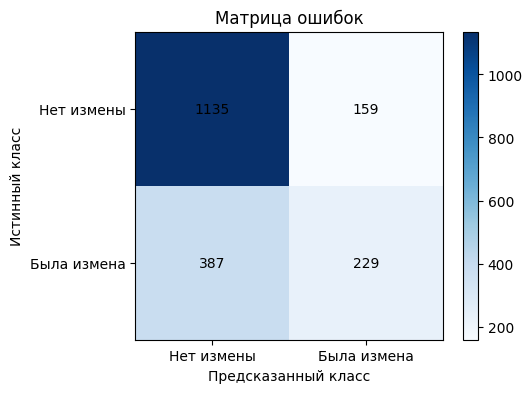

In [ ]:
# TODO:
cm = confusion_matrix(y_test, y_pred)
print(cm)
plot_confusion_heatmap(cm)

In [ ]:
tn, fp, fn, tp = cm.ravel()

print(f'Количество ложноположительных ошибок: {fp}')
print(f'Количество ложноотрицательных ошибок: {fn}')

Количество ложноположительных ошибок: 159
Количество ложноотрицательных ошибок: 387


### Короткий вывод

Ответьте кратко:
1. Какие ошибки встречаются чаще — ложноположительные или ложноотрицательные?
2. Почему одной accuracy недостаточно, чтобы это увидеть?

1. Ложноотрицательные ошибки встречаются чаще (`FN = 387`).
2. Одной `Accuracy` недостаточно, потому что эта метрика показывает долю правильных предсказаний от всех вариантов и не различает типы ошибок. При дисбалансе классов мы можем получить приемлемую `Accuracy`, но при этом модель может часто пропускать положительный класс, как в данной задаче (пропуск цели, ошибка 2 рода)

## 4. ROC-кривая и Precision-Recall кривая

Используя вероятности положительного класса:

1. постройте ROC-кривую и посчитайте `ROC-AUC`;
2. постройте Precision-Recall curve и посчитайте `Average Precision (AP)`.

Затем кратко сравните, что показывают эти две метрики.


In [ ]:
# TODO:
# ROC-кривая и ROC-AUC
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# TODO:
# PR-кривая и Average Precision (AP)
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test,
    y_proba
    )
ap_score = average_precision_score(y_test, y_proba)

print(f'ROC-AUC: {roc_auc:.4f}')
print(f'Average Precision (AP): {ap_score:.4f}')


ROC-AUC: 0.7397
Average Precision (AP): 0.5573


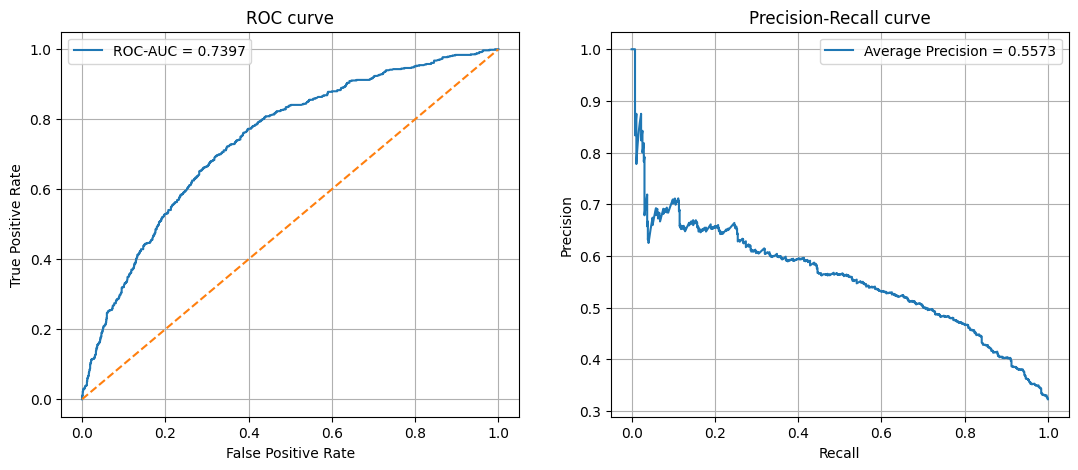

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_title("ROC curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(
    recall_curve,
    precision_curve,
    label=f"Average Precision = {ap_score:.4f}"
    )
axes[1].set_title("Precision-Recall curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(True)

plt.show()

### Короткий вывод

Ответьте кратко:
1. Что показывает ROC-AUC?
2. Что показывает Average Precision (AP)?
3. Почему AP часто полезнее, когда нас особенно интересует положительный класс?


1. `ROC-AUC` показывает способность модели различать положительный и отрицательный классы при различных порогах классификации. Чем ближе значение к 1, тем лучше. В данной задаче `ROC-AUC = 0.7397`, то есть модель разделяет классы заметно лучше случайной (0.5)
2. `Average Precision` показывает среднюю точность `Precision` по мере изменения `Recall` - обобщенно характеризует PR-кривую. В данной задаче `AP = 0.5573`: качество по положительному классу умеренное, не очень высокое, что согласуется с ранее полученным низким `Recall` для положительного класса.
3. `AP` полезна при дисбалансе классов и когда интересует положительный класс потому, что она она напрямую напрямую учитывает соотношение `Precision` и `Recall` для класса 1, тогда как `ROC-AUC` также сильно зависит от поведения на отрицательном классе.


## 5. Кросс-валидация

Сравните устойчивость качества модели тремя способами:

1. несколько обычных train/test split с разными `random_state`;
2. `KFold`;
3. `StratifiedKFold`.

Для сравнения используйте метрику **F1**.

In [ ]:
# TODO:
# Проведите 5 обычных разбиений train/test с random_state от 0 до 4
# Для каждого разбиения:
# 1. обучите новую модель
# 2. посчитайте F1 на test
# 3. сохраните результат

holdout_scores = []

for rs in range(5):
    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=rs,
        stratify=y
    )

    model_tmp = LogisticRegression(random_state=42)
    model_tmp.fit(X_train_tmp, y_train_tmp)
    pred_tmp = model_tmp.predict(X_test_tmp)
    score_tmp = f1_score(y_test_tmp, pred_tmp)
    holdout_scores.append(score_tmp)

holdout_scores = np.array(holdout_scores)
holdout_scores

array([0.45807771, 0.46121593, 0.44536941, 0.43835616, 0.4623323 ])

In [ ]:
# TODO:
# Посчитайте F1 через KFold и StratifiedKFold

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_cv = LogisticRegression(random_state=42)

kfold_scores = cross_val_score(model_cv, X, y, cv=kfold, scoring='f1')
skfold_scores = cross_val_score(model_cv, X, y, cv=skfold, scoring='f1')

cv_summary = pd.DataFrame({
    "method": ["Repeated holdout", "KFold", "StratifiedKFold"],
    "mean_f1": [holdout_scores.mean(), kfold_scores.mean(), skfold_scores.mean()],
    "std_f1": [holdout_scores.std(), kfold_scores.std(), skfold_scores.std()]
})

print('Сравнение средней F1 и стабильности методов валидации')
display(cv_summary)

Сравнение средней F1 и стабильности методов валидации


,method,mean_f1,std_f1
0,Repeated holdout,0.453070,0.009519
1,KFold,0.451919,0.023138
2,StratifiedKFold,0.450530,0.016658


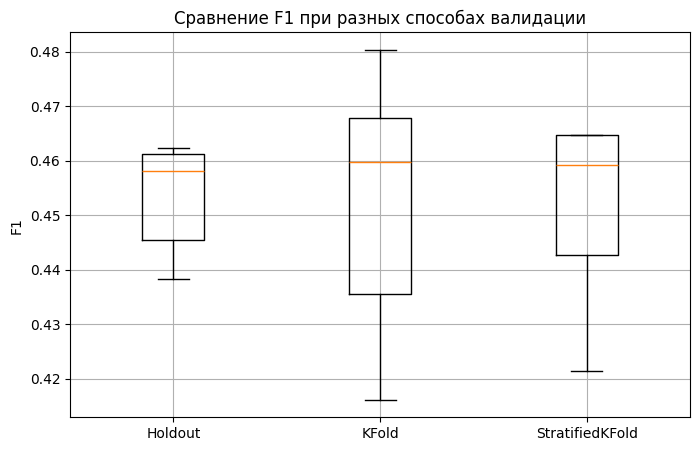

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(
    [holdout_scores, kfold_scores, skfold_scores],
    labels=["Holdout", "KFold", "StratifiedKFold"]
    )
plt.title("Сравнение F1 при разных способах валидации")
plt.ylabel("F1")
plt.grid(True)
plt.show()

### Короткий вывод

Ответьте кратко:
1. У какого способа оценки метрика самая стабильная?
2. Почему `StratifiedKFold` часто предпочтительнее для задач классификации?

1. В данной задаче самая стабильная метрика оказалась у метода Holdout (обычное разбиение на train/test): у него минимальное стандартное отклонение `std_f1 = 0.009519` при среднем значении f1 `mean_f1 = 0.453070`.
2. При этом `StratifiedKFold` часто предпочтительнее для задач классификации, потому что он сохраняет примерно одинаковую долю классов в каждом фолде. Это особенно важно при дисбалансе классов: оценка качества будет меньше зависеть от случайного состава конкретного фолда.

## 6. Сравнение L1- и L2-регуляризации

Чтобы не перегружать задание, сравните только 4 конфигурации:

- L1, `C = 0.01`
- L1, `C = 1`
- L2, `C = 0.01`
- L2, `C = 1`

Для каждой модели посчитайте:
- `train_accuracy`
- `test_accuracy`
- `train_f1`
- `test_f1`
- `train_roc_auc`
- `test_roc_auc`

Сравните результаты и сделайте вывод, есть ли признаки переобучения или недообучения.

In [ ]:
configs = [
    ("l1", 0.01),
    ("l1", 1.0),
    ("l2", 0.01),
    ("l2", 1.0),
]
configs

[('l1', 0.01), ('l1', 1.0), ('l2', 0.01), ('l2', 1.0)]

In [ ]:
# TODO:
# Пройдитесь циклом по configs, обучите модель для каждой конфигурации
# и сохраните метрики в список словарей

reg_results = []

for penalty, C in configs:
    model_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            penalty=penalty,
            C=C,
            solver='liblinear',
            random_state=42
            ))
        ])

    model_pipeline.fit(X_train, y_train)

    train_pred = model_pipeline.predict(X_train)
    test_pred = model_pipeline.predict(X_test)

    train_proba = model_pipeline.predict_proba(X_train)[:, 1]
    test_proba = model_pipeline.predict_proba(X_test)[:, 1]

    reg_results.append({
        "penalty": penalty,
        "C": C,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "train_f1": f1_score(y_train, train_pred),
        "test_f1": f1_score(y_test, test_pred),
        "train_roc_auc": roc_auc_score(y_train, train_proba),
        "test_roc_auc": roc_auc_score(y_test, test_proba),
    })

reg_results = pd.DataFrame(reg_results)
print('Сравнение метрик качества для разных вариантов регуляризации')
display(reg_results)

Сравнение метрик качества для разных вариантов регуляризации


,penalty,C,train_accuracy,test_accuracy,train_f1,test_f1,train_roc_auc,test_roc_auc
0,l1,0.01,0.723294,0.708901,0.423562,0.417191,0.738363,0.735156
1,l1,1.00,0.728680,0.715183,0.465281,0.457086,0.745421,0.739832
2,l2,0.01,0.727110,0.714660,0.457143,0.452261,0.743686,0.739049
3,l2,1.00,0.728232,0.714660,0.463922,0.456630,0.745392,0.739767


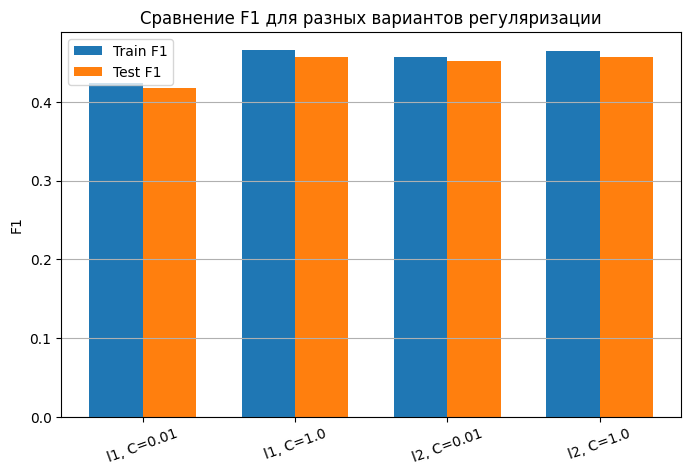

In [ ]:
plt.figure(figsize=(8, 5))
labels = reg_results["penalty"] + ", C=" + reg_results["C"].astype(str)
x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, reg_results["train_f1"], width=width, label="Train F1")
plt.bar(x + width/2, reg_results["test_f1"], width=width, label="Test F1")

plt.xticks(x, labels, rotation=20)
plt.ylabel("F1")
plt.title("Сравнение F1 для разных вариантов регуляризации")
plt.legend()
plt.grid(True, axis="y")
plt.show()

### Короткий вывод

Ответьте кратко:
1. Какая конфигурация даёт лучший результат на test?
2. Где сильнее заметно недообучение?
3. Есть ли явные признаки переобучения?
4. Какая регуляризация в этой задаче выглядит более удачной и почему?

1. Лучший результат на тестовых `F1` и `ROC-AUC`, а также и по `Accuracy` даёт `L1, C = 1.0`: `test_f1 = 0.4571`, `test_roc_auc = 0.7398` и `test_accuracy = 0.7151`.
2. Сильнее всего недообучение заметно при `L1, C = 0.01`: там самые низкие и train-, и test-метрики, особенно `F1 ≈ 0.4172`. Это признак сильной регуляризации.
3. Явных признаков переобучения нет: train- и test-метрики у всех конфигураций близки, большого разрыва между ними нет.
4. В этой задаче немного лучше выглядит `L1, C = 1.0`: эта конфигурация показала максимальные test-метрики, хотя отличие от `L2, C = 1.0` очень небольшое. При этом сильная `L1-регуляризация` с `C = 0.01` заметно ухудшила качество модели, тогда как для `L2` влияние уменьшения `C` оказалось значительно слабее.

# Итоговый вывод

Напишите 5–8 предложений, в которых кратко ответите:

1. Почему accuracy недостаточно как единственная метрика?
2. Что дополнительно дали F1, ROC-AUC и Average Precision (AP)?
3. Зачем нужна кросс-валидация?
4. Как регуляризация помогает контролировать переобучение?
5. Какая модель в этой работе показала себя лучше всего?


`Accuracy` недостаточно использовать как единственную метрику, потому что при дисбалансе классов она может выглядеть приемлемо, даже если модель плохо распознаёт положительный класс (как в данной задаче). `F1` дополнительно показал качество именно по классу 1 с учётом баланса между `Precision` и `Recall` (`F1 = 0.456`), а `ROC-AUC` оценил способность модели разделять классы при разных порогах (`ROC-AUC = 0.740`). `Average Precision` оказался полезен для оценки качества положительного класса при изменении `Recall` и особенно важен при дисбалансе (`AP = 0.557`). Кросс-валидация позволила проверить, насколько устойчиво качество модели к разным разбиениям данных, и показала, что средний `F1` у разных способов валидации близок (`Repeated Holdout = 0.453`, `KFold = 0.452` и  `StratifiedKFold = 0.451`), хотя разброс отличается (стандартное отклонение 0.010, 0.023 и 0.017 соответственно). Регуляризация помогает ограничивать величину коэффициентов модели и тем самым снижать риск переобучения, однако слишком сильная `L1-регуляризация` при `C = 0.01` привела к признакам недообучения. Явного переобучения в рассмотренных конфигурациях не наблюдалось, так как train- и test-метрики были близки. Лучшие результаты дали модели с `C = 1.0`: у `L1` немного лучше все test-метрики, чем у `L2`.